In [1]:
import matplotlib.pyplot as plt
import subprocess

#compile
subprocess.run(["gcc", "-O2", "-w", "../es1A.c", "-o", "es1A"])
subprocess.run(["gcc", "-O2", "-w", "../es1B.c", "-o", "es1B"])

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
import random
import string
import time
import statistics
import subprocess

def gen(n): #build N names correctly
    used = set()
    last = random.choice(string.ascii_lowercase)
    res = []

    for _ in range(n):
        while True:
            s = last + ''.join(random.choices(string.ascii_lowercase, k=8))
            if s not in used:
                break
        used.add(s)
        res.append(s)
        last = s[-1]
    # Formatting as requested
    return str(n) + "\n" + "\n".join(res) + "\n" #can i tolgiere \n

def measure_once(exe, data):
    # Single full run, includes process startup cost.
    t0 = time.perf_counter()
    p = subprocess.Popen([exe], stdin=subprocess.PIPE, stdout=subprocess.DEVNULL, text=True)
    p.communicate(data)
    return time.perf_counter() - t0


def measure(exe, data, repeats=7, warmup=2):
    # Warmup (cache, page faults, etc.).
    for _ in range(warmup):
        measure_once(exe, data)

    # Median of real test
    samples = [measure_once(exe, data) for _ in range(repeats)]
    return statistics.median(samples)



sizes4test = list(range(1, 800020, 2000))
datasets = {n: gen(n) for n in sizes4test}
timesA, timesB = [], []
for n in sizes4test: 
    data = datasets[n]
    timesA.append(measure("./es1A", data))
    timesB.append(measure("./es1B", data))

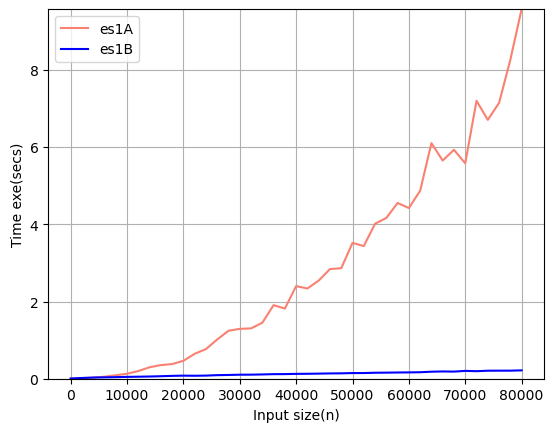

In [ ]:
# 'blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'navy', 'teal', 'lime', 'maroon', 'khaki', 'gold', 'silver', 'coral', 'salmon', 'tomato', 'turquoise', 'violet', 'indigo',
plt.plot(sizes4test, timesA, label="es1A", color="red")
plt.plot(sizes4test, timesB, label="es1B", color="blue")
plt.xlabel("Input size(n)")
plt.ylabel("Time exe(secs)")
plt.ylim(0, max(3.5, max(timesA), max(timesB)))
plt.legend()
plt.grid()
plt.show()